In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exercício 1

In [17]:
# Definição dos dados
trimestres = ["1º Trimestre", "2º Trimestre", "3º Trimestre", "4º Trimestre"]
demanda = [500, 400, 300, 500] # Demanda por trimestre
estoque_inicial = 50 # Estoque inicial
custo_turno_normal = 5 # Custo por unidades produzidas (custo fixo)
custo_turno_extra = 7.5 # Custo por unidades produzidas (custo fixo)
custo_subcontratacao = 10 # Custo por unidades produzidas (custo fixo)
custo_estoque = 5  # Por unidade por trimestre (custo variável)
custo_atraso = 10  # Por unidade por trimestre (custo variável)


# Estratégias de Produção

In [18]:
producao_estrategias = {
    "E1 - Produção Normal (400 unid.)": [400, 400, 400, 400], # Produção normal com atrasos de entrega
    "E2 - Produção Normal + Turno Extra": [400, 400, 400, 400],  # Adiciona turno extra conforme necessário
    "E3 - Normal + Extra + Subcontratação": [400, 400, 400, 400],  # Sem estoque médio, sem atrasos
    "E4 - Produção Média (425 unid.)": [425, 425, 425, 425]
}


# Cálculo dos estoques, atrasos e custos

In [19]:
resultados = []
for estrategia, producao in producao_estrategias.items():
    estoque = estoque_inicial
    atraso = 0
    custo_total = 0
    dados = []

    for i in range(4):
        producao_atual = producao[i]
        demanda_atual = demanda[i]

        # Cálculo do estoque e atraso
        saldo = estoque + producao_atual - demanda_atual
        if saldo >= 0:
            estoque = saldo  # Sem atraso
            atraso = 0
        else:
            atraso = abs(saldo)  # Define atraso
            estoque = 0  # Estoque zerado

        # Cálculo dos custos
        custo_producao = producao_atual * custo_turno_normal
        custo_extra = max(0, demanda_atual - producao_atual) * custo_turno_extra if estrategia == "E2 - Produção Normal + Turno Extra" else 0
        custo_sub = max(0, demanda_atual - producao_atual) * custo_subcontratacao if estrategia == "E3 - Normal + Extra + Subcontratação" else 0
        custo_estoque_total = estoque * custo_estoque
        custo_atraso_total = atraso * custo_atraso

        # Cálculo do custo total
        custo_total += custo_producao + custo_extra + custo_sub + custo_estoque_total + custo_atraso_total

        dados.append([trimestres[i], demanda_atual, producao_atual, estoque, atraso, custo_producao, custo_extra, custo_sub, custo_estoque_total, custo_atraso_total, custo_total])

    df_resultado = pd.DataFrame(dados, columns=["Trimestre", "Demanda", "Produção", "Estoque Final", "Atraso", "Custo Produção", "Custo Extra", "Custo Subcontratação", "Custo Estoque", "Custo Atraso", "Custo Total"])
    resultados.append((estrategia, df_resultado))


# Exibir os resultados

In [20]:
import ace_tools_open as tools

for estrategia, df in resultados:
    tools.display_dataframe_to_user(name=f"Resultados - {estrategia}", dataframe=df)


Resultados - E1 - Produção Normal (400 unid.)


Resultados - E2 - Produção Normal + Turno Extra


Resultados - E3 - Normal + Extra + Subcontratação


Resultados - E4 - Produção Média (425 unid.)


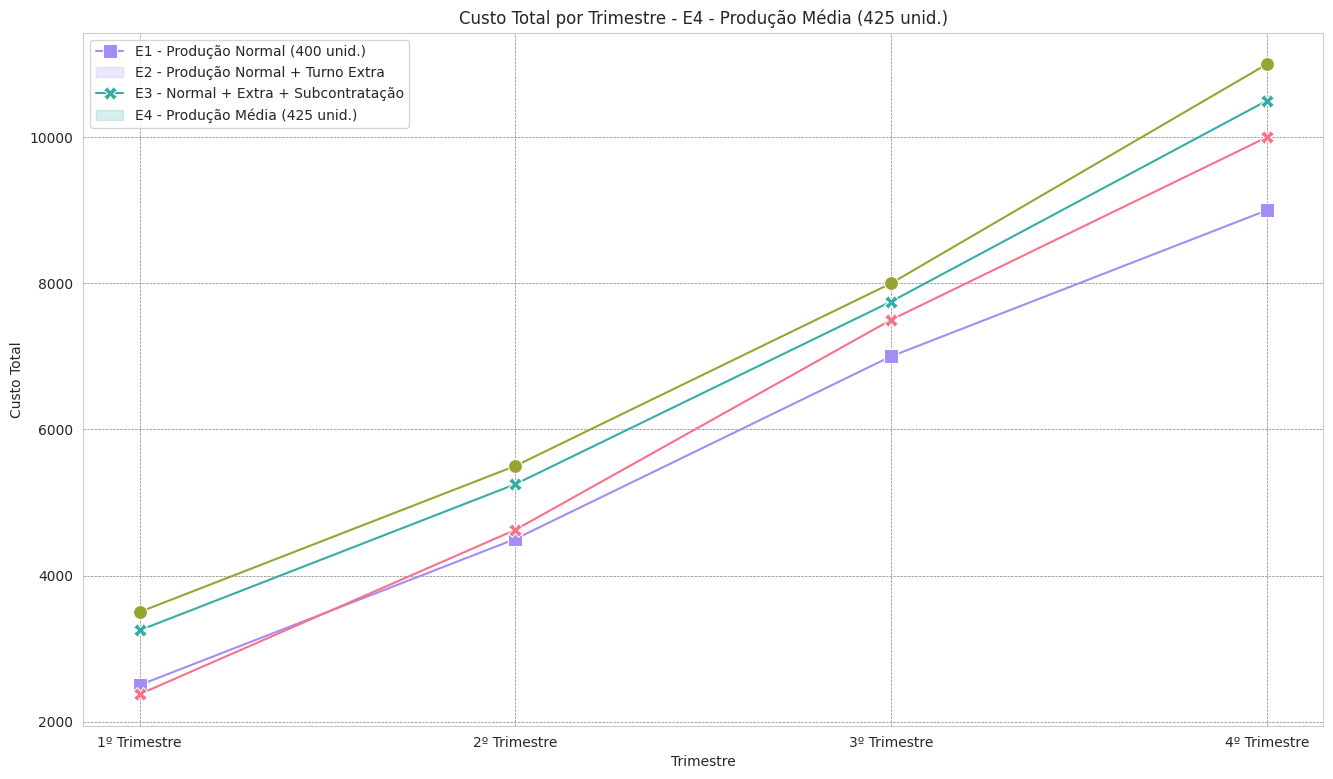

In [25]:
# Exibir gráficos
plt.figure(figsize=(16, 9))
markers = ["o", "s", "D", "X"]
colors = sns.color_palette("husl", len(resultados))
for estrategia, df in resultados:
    mark = sorted(markers, key=lambda _: np.random.rand())
    sns.lineplot(data=df, x="Trimestre", y="Custo Total", marker=mark.pop(), markersize=10, color=colors.pop())
    plt.legend([estrategia for estrategia, _ in resultados], loc="upper left")

plt.ylabel("Custo Total")
plt.xlabel("Trimestre")
plt.title(f"Custo Total por Trimestre - {estrategia}")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.show()